<h1> <center>GIS - Mini Project 2 </center>

In [332]:
#Import Required Library
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import Point
from matplotlib import pyplot as plt
import matplotlib_map_utils as mapu
import matplotlib_map_utils as mu

In [333]:
#Change my working directory
os.getcwd()
path =r'C:/Users/aksha/Downloads/InclassAssignment2'
os.chdir(path)

In [396]:
# Load the transmissivity values and Jefferson County boundaries
Tvalues = gpd.read_file("pwells2.gpkg")

# Load the Jefferson County map (WGS84)
fJeff = 'Jefferson.gpkg'
Jeff = gpd.read_file(fJeff)

# Reproject the map to EPSG:6350 (Albers Equal Area)
Jeff = Jeff.to_crs("EPSG:6350")

# Save the reprojected map to a new GeoPackage
Jeff.to_file('Jefferson_6350.gpkg', driver='GPKG')

# Check the columns in Tvalues
print(Tvalues.columns)

Index(['field_1', 'StateWellNumber', 'County', 'LongitudeDD', 'LatitudeDD',
       'LandSurfaceElevation', 'WellDepth', 'WaterElevation', 'DepthFromLSD',
       'Interpolated', 'TSQFTD', 'top_1', 'bot_1', 'bot_2', 'bot_3', 'bot_4',
       'bot_5', 'bot_6', 'geometry'],
      dtype='object')


In [335]:
# Load the transmissivity values GeoDataFrame
Tvalues = gpd.read_file("pwells2.gpkg")  # Adjust the path as needed

# Get the specific column headers
specific_columns = ['field_1', 'LongitudeDD', 'LatitudeDD', 'TSQFTD']
column_headers = Tvalues[specific_columns].columns.tolist()

# Print the specific column headers
print("Column Headers:", column_headers)

# Print all column data for the selected columns
print(Tvalues[specific_columns])

Column Headers: ['field_1', 'LongitudeDD', 'LatitudeDD', 'TSQFTD']
   field_1  LongitudeDD  LatitudeDD  TSQFTD
0        0   -94.266112   30.134722    3358
1        3   -94.271389   30.159167    3351
2       16   -94.407223   30.073611    3190
3       25   -94.275555   30.089167    3333
4       26   -94.291667   30.096389    3316
5      101   -93.908612   29.968055    3247
6      190   -94.199722   29.742500    2849
7      191   -94.164167   29.741389    2905
8      194   -94.072778   29.667778    3032


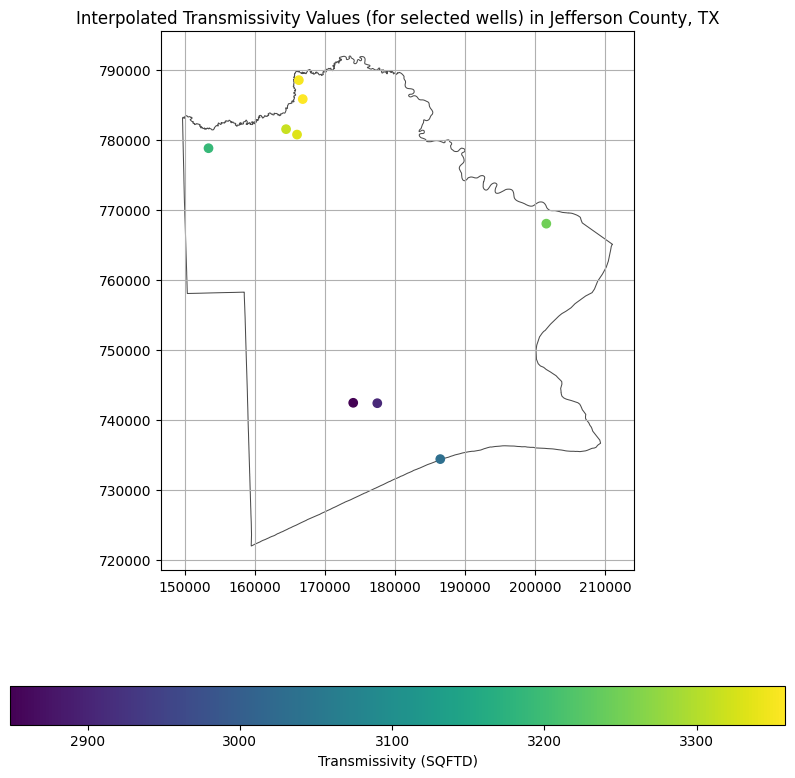

In [336]:
# Ensure both GeoDataFrames are in EPSG:6350
Tvalues = Tvalues.to_crs(epsg=6350)
Jeff = Jeff.to_crs(epsg=6350)

# Plotting the map
fig, ax = plt.subplots(figsize=(10, 10))

# Plot Jefferson County boundary
Jeff.plot(ax=ax, color='none', edgecolor='black', alpha=0.7, linewidth=0.75)

# Plot transmissivity values as a color-coded layer
# Assuming 'Transmissivity' is the column name in Tvalues containing the interpolated transmissivity values
Tvalues.plot(column='TSQFTD', ax=ax, cmap='viridis', legend=True,
             legend_kwds={'label': "Transmissivity (SQFTD)", 'orientation': "horizontal"})

# Add title and grid
plt.title("Interpolated Transmissivity Values (for selected wells) in Jefferson County, TX")
plt.grid(visible=True)

# Display the map
plt.show()

In [337]:
# Print the CRS of both GeoDataFrames
print("CRS of Tvalues:", Tvalues.crs)
print("CRS of Jeff:", Jeff.crs)

CRS of Tvalues: EPSG:6350
CRS of Jeff: EPSG:6350


In [338]:
#Read the well main text
a = pd.read_csv('WellMain.txt', sep = '|', encoding = 'ISO-8859-1',low_memory=False)

In [339]:
a.head()
a.columns

Index(['StateWellNumber', 'County', 'RiverBasin', 'GMA', 'RWPA', 'GCD',
       'AquiferCode', 'AquiferCodeDescription', 'AquiferId', 'Aquifer',
       'Classification', 'AquiferPickMethod', 'LatitudeDD', 'Dlat', 'Mlat',
       'Slat', 'LongitudeDD', 'Dlong', 'Mlong', 'Slong', 'CoordinateSource',
       'Owner', 'Driller', 'WellDepth', 'DepthSource', 'LandSurfaceElevation',
       'LandSurfaceElevationMethod', 'DrillingStartDate', 'DrillingMonth',
       'DrillingDay', 'DrillingYear', 'DrillingEndDate', 'DrillingMethod',
       'BoreHoleCompletion', 'WellType', 'Pump', 'PowerType', 'WellUse',
       'WaterLevelStatus', 'CurrentWaterLevelWell', 'WaterQualityAvailable',
       'CurrentWaterQualityWell', 'ReportingAgency', 'OtherDataAvailable',
       'Remarks', 'WellReportTrackingNumber', 'PluggingReportTrackingNumber',
       'USGSSiteNumber', 'TCEQSourceId', 'GCDWellNumber', 'OwnerWellNumber',
       'OtherWellNumber', 'PreviousStateWellNumber', 'CreatedDate',
       'LastUpdateDate'],


In [340]:
cols= ['StateWellNumber','County','LongitudeDD','LatitudeDD','LandSurfaceElevationMethod','WellDepth']

In [341]:
#Create a sub set of Jefferson Wells in rows and selected columns from above. Row and columns both are being filtered.
asub = a.loc[a.County=='Jefferson', cols]
asub.head()
asub.describe()
len(asub)

428

In [342]:
#Read water levels from WaterlevelsMajor.txt and subset those for the Jefferson Aquifer
fname = 'WaterLevelsMajor.txt'
b = pd.read_csv(fname, sep = '|', encoding = "ISO-8859-1", low_memory=False)
b.head(5)

,StateWellNumber,County,Aquifer,Status,MeasurementMonth,MeasurementDay,MeasurementYear,MeasurementDate,MeasurementTime,DepthFromLSD,LandElevation,LandElevationMethod,WaterElevation,MeasurementNumber,MeasuringAgency,MethodOfMeasurement,Remarks,Comments,CreatedDate,LastUpdateDate
0,140901,Dallam,Ogallala,Publishable,4.0,16.0,1958.0,1958-04-16,NaN,73.00,4669.0,Interpolated From Topo Map,4596.00,1,Other or Source of Measurement Unknown,Unknown,Accurately reflects water level conditions,NaN,NaN,NaN
1,140901,Dallam,Ogallala,Publishable,4.0,6.0,1960.0,1960-04-06,NaN,77.00,4669.0,Interpolated From Topo Map,4592.00,1,Other or Source of Measurement Unknown,Unknown,Accurately reflects water level conditions,NaN,NaN,NaN
2,140901,Dallam,Ogallala,Publishable,1.0,5.0,1961.0,1961-01-05,NaN,79.10,4669.0,Interpolated From Topo Map,4589.90,1,Texas Water Development Board,Steel Tape,NaN,NaN,NaN,NaN
3,140901,Dallam,Ogallala,Publishable,1.0,19.0,1962.0,1962-01-19,NaN,76.63,4669.0,Interpolated From Topo Map,4592.37,1,Texas Water Development Board,Steel Tape,NaN,NaN,NaN,NaN
4,140901,Dallam,Ogallala,Publishable,1.0,9.0,1963.0,1963-01-09,NaN,87.70,4669.0,Interpolated From Topo Map,4581.30,1,Texas Water Development Board,Steel Tape,NaN,NaN,NaN,NaN


In [343]:
bcol = ['StateWellNumber','MeasurementYear','WaterElevation', 'DepthFromLSD', 'LandElevation']
bsub = b.loc[b.County=='Jefferson', bcol]
bsub.head()
len(bsub) #total sample records within the gulf coast within th edatabase

977

In [344]:
#Extract Water Elevation
WLGCNumeric = bsub[['StateWellNumber', 'WaterElevation', 'DepthFromLSD']]
WLMean = WLGCNumeric.groupby('StateWellNumber').mean() #Temporal mean
WLMean.dropna(inplace=True)
print(WLMean)


                 WaterElevation  DepthFromLSD
StateWellNumber                              
6154901               23.100000      6.900000
6154902              -17.178889     45.178889
6154904              -17.287143     44.287143
6154905              -25.338571     51.338571
6155504               32.000000    -18.000000
6155505               14.570000     -1.570000
6155506               16.150000     -2.150000
6155701               27.000000      9.000000
6155703               21.000000      5.000000
6155707              -27.187419     50.187419
6155708              -12.524444     38.524444
6155803               24.000000      8.000000
6155805               22.500000     11.500000
6156701               20.247500     -2.247500
6156702                9.592000      7.408000
6161308               30.600000      4.400000
6161602               29.300000      6.700000
6161801               41.000000      4.000000
6161803               33.600000      7.400000
6161804               31.000000   

In [397]:
#Merge Avg Water Level and Well info into one table
WellData = pd.merge(asub,WLMean, on = 'StateWellNumber', how ='inner')
WellData = WellData.loc[WellData.DepthFromLSD > 0]
WellData.to_csv('JGCMeanWL.csv') #Mske s copy for future use
WellData.head()
len(WellData)

185

In [346]:
#Create geometry from lat &lon columns
geometry = [Point(xy) for xy in zip(WellData['LatitudeDD'], WellData['LongitudeDD'])]
#Turn pandas df to Geodf.
Wellgpf = gpd.GeoDataFrame(WellData, geometry=geometry)
#Set a CRS
Wellgpf.set_crs(epsg=4326, inplace=True)
pd.set_option('display.max_rows', None)
print(Wellgpf)
Wellgpf.columns

     StateWellNumber     County  LongitudeDD  LatitudeDD  \
0            6154901  Jefferson   -94.266112   30.134722   
1            6154902  Jefferson   -94.271111   30.159167   
2            6154904  Jefferson   -94.270278   30.161667   
3            6154905  Jefferson   -94.271389   30.159167   
7            6155701  Jefferson   -94.213889   30.130555   
8            6155703  Jefferson   -94.228055   30.161389   
9            6155707  Jefferson   -94.232492   30.153269   
10           6155708  Jefferson   -94.232500   30.156945   
11           6155803  Jefferson   -94.194445   30.143889   
12           6155805  Jefferson   -94.185278   30.156389   
14           6156702  Jefferson   -94.098889   30.131111   
15           6161308  Jefferson   -94.404723   30.095278   
16           6161602  Jefferson   -94.407223   30.073611   
17           6161801  Jefferson   -94.436667   30.015834   
18           6161803  Jefferson   -94.425278   30.036111   
19           6161804  Jefferson   -94.41

Index(['StateWellNumber', 'County', 'LongitudeDD', 'LatitudeDD',
       'LandSurfaceElevationMethod', 'WellDepth', 'WaterElevation',
       'DepthFromLSD', 'geometry'],
      dtype='object')

In [347]:
Wellgpf = Wellgpf.dropna() 

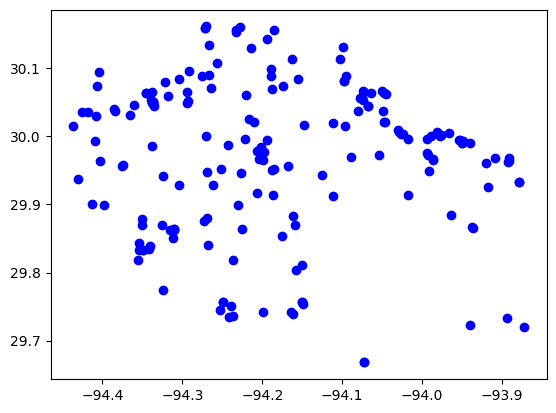

In [348]:
plt.scatter(Wellgpf['LongitudeDD'], Wellgpf['LatitudeDD'], marker='o', color='b', label='Well Locations')

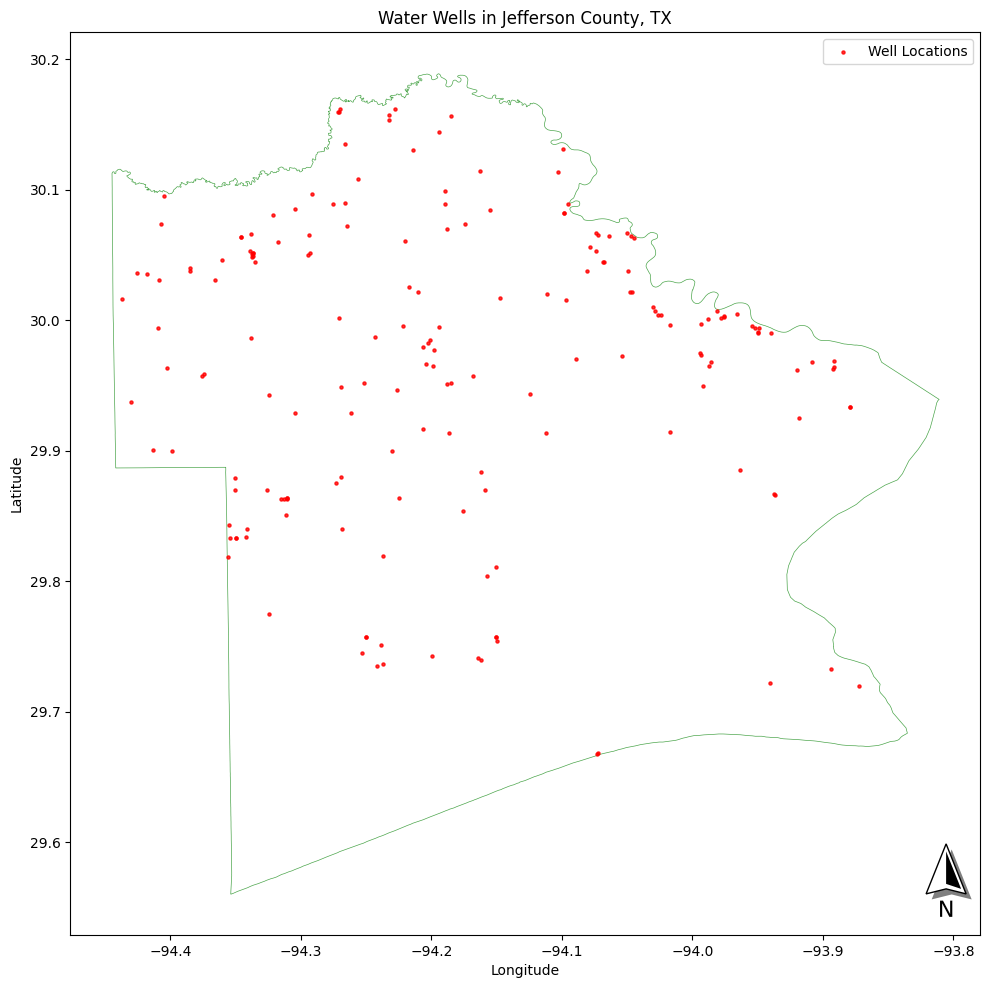

In [398]:
# Subset the Jefferson County wells data and select columns
cols = ['StateWellNumber', 'County', 'LongitudeDD', 'LatitudeDD', 'LandSurfaceElevation', 'WellDepth']
asub = a.loc[a.County == 'Jefferson', cols]

# Read and subset the water level data
fname = 'WaterLevelsMajor.txt'
b = pd.read_csv(fname, sep='|', encoding="ISO-8859-1", low_memory=False)
bcol = ['StateWellNumber', 'MeasurementYear', 'WaterElevation', 'DepthFromLSD', 'LandElevation']
bsub = b.loc[b.County == 'Jefferson', bcol]

# Extract water elevation and calculate the mean
WLGCNumeric = bsub[['StateWellNumber', 'WaterElevation', 'DepthFromLSD']]
WLMean = WLGCNumeric.groupby('StateWellNumber').mean()
WLMean.dropna(inplace=True)

# Merge well data with water level data
WellData = pd.merge(asub, WLMean, on='StateWellNumber', how='inner')
WellData = WellData.loc[WellData.DepthFromLSD > 0]  # Filter valid wells

# Create geometry from latitude and longitude
geometry = [Point(xy) for xy in zip(WellData['LongitudeDD'], WellData['LatitudeDD'])]

# Turn the pandas DataFrame into a GeoDataFrame
Wellgpf = gpd.GeoDataFrame(WellData, geometry=geometry)

# Set the CRS to EPSG:4326 (WGS84 for latitude/longitude)
Wellgpf.set_crs(epsg=4326, inplace=True)

# Drop any rows with missing data
Wellgpf = Wellgpf.dropna()

# Optionally, reproject to another CRS (EPSG:6350 for meters, if needed)
# Wellgpf = Wellgpf.to_crs(epsg=6350)

# Plot the map of wells using GeoPandas
# Load the base map of Jefferson County (make sure your map file is available)
fJeff = 'Jefferson.gpkg'
Jeff = gpd.read_file(fJeff)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))
Jeff.plot(ax=ax, color='w', edgecolor='g', alpha=0.7, linewidth=0.5)

# Plot the water wells (Wellgpf) on top of the base map
Wellgpf.plot(ax=ax, color='red', markersize=5, alpha=0.8, marker='o', label="Well Locations")

# Add a title and customize the plot
plt.title("Water Wells in Jefferson County, TX")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

# Add a north arrow (assuming `mu.north_arrow` is defined and used)
mapu.north_arrow.north_arrow(ax=ax, location='lower right', rotation={"degrees": 0})

# Set aspect ratio and adjust layout
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()

# Show the plot
plt.show()


In [350]:
selected = [6154901,6161602,6162303,6162305,6424502,6301301,6154905,6423302,6423201]
pwells = WellData[WellData['StateWellNumber'].isin(selected)]

In [351]:
pwells

,StateWellNumber,County,LongitudeDD,LatitudeDD,LandSurfaceElevation,WellDepth,WaterElevation,DepthFromLSD
0,6154901,Jefferson,-94.266112,30.134722,30.0,21.0,23.100000,6.900000
3,6154905,Jefferson,-94.271389,30.159167,26.0,572.0,-25.338571,51.338571
16,6161602,Jefferson,-94.407223,30.073611,36.0,300.0,29.300000,6.700000
25,6162303,Jefferson,-94.275555,30.089167,38.0,102.0,30.000000,8.000000
26,6162305,Jefferson,-94.291667,30.096389,39.0,208.0,31.000000,8.000000
101,6301301,Jefferson,-93.908612,29.968055,12.0,1000.0,-3.320000,15.320000
190,6423201,Jefferson,-94.199722,29.742500,5.0,178.0,1.800000,3.200000
191,6423302,Jefferson,-94.164167,29.741389,3.0,70.0,1.900000,1.100000
194,6424502,Jefferson,-94.072778,29.667778,5.0,10.0,2.000000,3.000000


In [352]:
pwells.to_csv('pumpwells.csv')

In [399]:
# Load mean water levels file and convert to AEA projection
mean_water_levels_gdf = gpd.read_file("pwells2.gpkg")
mean_water_levels_gdf = mean_water_levels_gdf.to_crs("EPSG:6350")  # AEA projection

# Compute X and Y coordinates in AEA
mean_water_levels_gdf['X'] = mean_water_levels_gdf.geometry.x
mean_water_levels_gdf['Y'] = mean_water_levels_gdf.geometry.y
print(mean_water_levels_gdf[['X', 'Y']].head())

               X              Y
0  166834.846987  785849.276114
1  166277.793526  788553.162588
2  153372.144389  778829.427503
3  166018.090732  780777.008066
4  164452.693490  781550.465279


In [400]:
import statsmodels.api as sm

# Set up data for regression
X = mean_water_levels_gdf[['X', 'Y']]
X = sm.add_constant(X)  # Add intercept
y = mean_water_levels_gdf['WaterElevation']  # Assuming WaterElevation represents Hydraulic Head

# Fit linear regression model
model = sm.OLS(y, X).fit()
gradient_x, gradient_y = model.params['X'], model.params['Y']
# Output gradients
print(f"Gradient with respect to X: {gradient_x}")
print(f"Gradient with respect to Y: {gradient_y}")

Gradient with respect to X: -0.0006363480936252356
Gradient with respect to Y: 3.870529823687301e-05


In [402]:
# Resultant gradient
resultant_gradient = np.sqrt(gradient_x**2 + gradient_y**2)
print("Resultant Gradient:", resultant_gradient)

Resultant Gradient: 0.0006375241143455492


In [403]:
from shapely.geometry import Polygon

# Define the capture zone polygon (adjust as needed)
polygon_points = [(0, 0), (0, -resultant_gradient), (resultant_gradient, 0)]
capture_zone_polygon = Polygon(polygon_points)
print(f"Capture Zone Polygon Coordinates: {polygon_points}")

Capture Zone Polygon Coordinates: [(0, 0), (0, -0.0006375241143455492), (0.0006375241143455492, 0)]


In [404]:
capture_zone_gdf = gpd.GeoDataFrame(geometry=[capture_zone_polygon], crs="EPSG:6350")
print(capture_zone_gdf)

                                  geometry
0  POLYGON ((0 0, 0 -0.001, 0.001 0, 0 0))


In [405]:
angle = np.degrees(np.arctan2(gradient_y, gradient_x))
print(f"Calculated Rotation Angle (degrees): {angle}")

# Rotate the capture zone polygon around its centroid by the calculated angle
rotated_capture_zone_polygon = rotate(capture_zone_polygon, angle, origin='centroid')
print("Rotated Capture Zone Polygon Coordinates:")
print(rotated_capture_zone_polygon)

# Convert rotated polygon into a GeoDataFrame for further operations
rotated_capture_zone_gdf = gpd.GeoDataFrame(geometry=[rotated_capture_zone_polygon], crs="EPSG:6350")


Calculated Rotation Angle (degrees): 176.5193240526622
Rotated Capture Zone Polygon Coordinates:
POLYGON ((0.0004117223032446 -0.0004375258354026, 0.0004504276014815 0.0001988222582227, -0.0002246257903806 -0.0003988205371657, 0.0004117223032446 -0.0004375258354026))


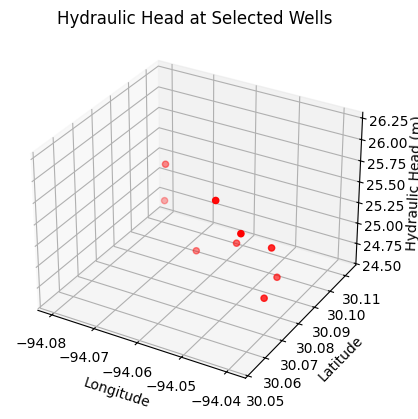

In [406]:
from mpl_toolkits.mplot3d import Axes3D
# Coordinates for 9 wells
well_ids = [6164505, 6161602, 6162303, 6162305, 6424502, 6301301, 6154905, 6423302, 6423201]
latitude = [30.053056, 30.066944, 30.071256, 30.086445, 30.056632, 30.089123, 30.095601, 30.102345, 30.112678]
longitude = [-94.03889, -94.03889, -94.03906, -94.04322, -94.04567, -94.05355, -94.06556, -94.07567, -94.08033]
hydraulic_head = [26.0, 24.999999, 25.5, 24.8, 26.2, 25.0, 24.6, 25.4, 24.7]

# Create a figure for 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the wells in 3D space
ax.scatter(longitude, latitude, hydraulic_head, c='r', marker='o')

# Labels for the axes
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Hydraulic Head (m)')

# Title
plt.title('Hydraulic Head at Selected Wells')

# Show the plot
plt.show()

Plotted Jefferson County Map.
Overlayed the translated capture zone on the map.


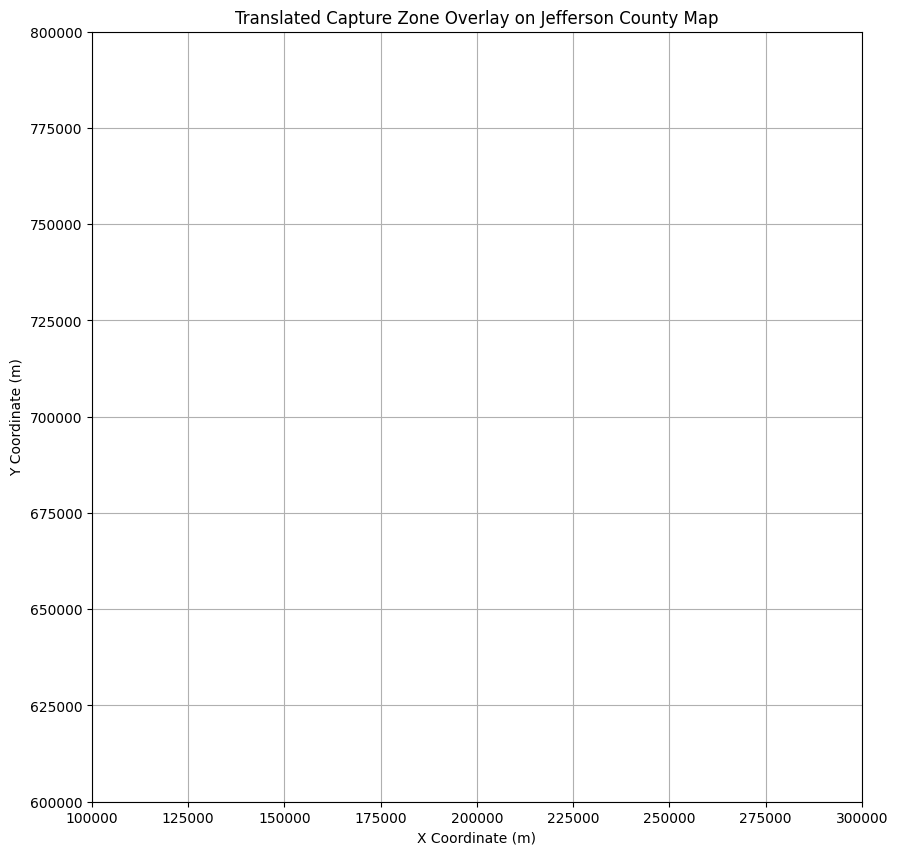

In [413]:
import numpy as np
from shapely import affinity
from shapely.geometry import Polygon
import geopandas as gpd
import matplotlib.pyplot as plt

# Step 11-13 code, assuming 'rotated_capture_zone_polygon' and 'Jeff' are already defined

# Step 12: Translate the capture zone polygon to match the approximate Jefferson County area
capture_zone_polygon_translated = affinity.translate(rotated_capture_zone_polygon, xoff=200000, yoff=700000)

# Convert the translated polygon to a GeoDataFrame
translated_capture_zone_gdf = gpd.GeoDataFrame(geometry=[capture_zone_polygon_translated], crs="EPSG:6350")

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the Jefferson County map
Jeff.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.75)
print("Plotted Jefferson County Map.")

# Overlay the translated capture zone
translated_capture_zone_gdf.plot(ax=ax, color='blue', alpha=0.5, edgecolor='darkblue')
print("Overlayed the translated capture zone on the map.")

# Adjust the plot view limits to focus on the area where the polygon is located
ax.set_xlim(100000, 300000)
ax.set_ylim(600000, 800000)

# Additional plot embellishments
plt.title("Translated Capture Zone Overlay on Jefferson County Map")
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.grid(True)
plt.show()


Rotated capture zone polygon exported to 'rotated_capture_zone.gpkg'
